# Atlassian Datathon EDA

Quick exploration of the customer, support ticket and product usage data.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


C:\Users\Maxim\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load the data

In [2]:
customers = pd.read_csv("data/customers.csv")
tickets = pd.read_csv("data/customer_support_tickets.csv")
usage = pd.read_csv("data/product_usage.csv")

print("Customers:", customers.shape)
print("Tickets:", tickets.shape)
print("Usage:", usage.shape)


Customers: (8320, 10)
Tickets: (8469, 16)
Usage: (42210, 8)


## Have a look

In [3]:
customers.head()

,Customer ID,Customer Name,Customer Email,Customer Age,Customer Gender,Industry,Region,Company Size,Plan Type,Account Created Date
0,CUST00001,Robert Downs,aanderson@example.com,42,Male,Technology,Europe,201-500,Standard,2020-12-20
1,CUST00002,Cesar Jensen,aanderson@example.net,35,Other,Retail,Asia-Pacific,201-500,Standard,2020-06-15
2,CUST00003,Angela Tran,aarnold@example.com,52,Other,Education,Asia-Pacific,1000+,Free,2020-10-24
3,CUST00004,Justin Estrada,aaron01@example.com,45,Female,Professional Services,Europe,11-50,Enterprise,2019-11-13
4,CUST00005,James Santos,aaron49@example.org,22,Other,Professional Services,Australia & New Zealand,501-1000,Standard,2019-04-21


In [4]:
tickets.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [5]:
usage.head()

,Customer ID,Product,Month,Active Days,Sessions,Product Actions,Collaborators,Integrations Used
0,CUST00001,Loom,2023-01,3,7,49,12,3
1,CUST00001,Loom,2023-02,4,7,22,4,4
2,CUST00001,Loom,2023-03,5,10,37,5,3
3,CUST00001,Loom,2023-04,4,7,47,12,1
4,CUST00001,Loom,2023-05,5,10,34,4,3


## Columns and data types

In [6]:
print("CUSTOMERS")
display(customers.info())

print("\nTICKETS")
display(tickets.info())

print("\nUSAGE")
display(usage.info())


CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 8320 entries, 0 to 8319
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Customer ID           8320 non-null   str  
 1   Customer Name         8320 non-null   str  
 2   Customer Email        8320 non-null   str  
 3   Customer Age          8320 non-null   int64
 4   Customer Gender       8320 non-null   str  
 5   Industry              8320 non-null   str  
 6   Region                8320 non-null   str  
 7   Company Size          8320 non-null   str  
 8   Plan Type             8320 non-null   str  
 9   Account Created Date  8320 non-null   str  
dtypes: int64(1), str(9)
memory usage: 1.4 MB


None


TICKETS
<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Status                 8469 non-null   str    
 10  Resolution                    2769 non-null   str    
 11  Ticket Priority               8469 non-null   str    
 12  Ticket Channel                8469 non-null   str    
 13  First

None


USAGE
<class 'pandas.DataFrame'>
RangeIndex: 42210 entries, 0 to 42209
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Customer ID        42210 non-null  str  
 1   Product            42210 non-null  str  
 2   Month              42210 non-null  str  
 3   Active Days        42210 non-null  int64
 4   Sessions           42210 non-null  int64
 5   Product Actions    42210 non-null  int64
 6   Collaborators      42210 non-null  int64
 7   Integrations Used  42210 non-null  int64
dtypes: int64(5), str(3)
memory usage: 3.5 MB


None

## Missing values

In [7]:
def missing_values(df):
    return (
        pd.DataFrame({
            "missing": df.isna().sum(),
            "missing_%": df.isna().mean() * 100
        })
        .sort_values("missing_%", ascending=False)
    )

missing_values(tickets)


,missing,missing_%
Customer Satisfaction Rating,5700,67.304286
Time to Resolution,5700,67.304286
Resolution,5700,67.304286
First Response Time,2819,33.286102
Ticket ID,0,0.000000
Customer Name,0,0.000000
Customer Email,0,0.000000
Customer Age,0,0.000000
Ticket Type,0,0.000000
Date of Purchase,0,0.000000


In [8]:
missing_values(customers)

,missing,missing_%
Customer ID,0,0.0
Customer Name,0,0.0
Customer Email,0,0.0
Customer Age,0,0.0
Customer Gender,0,0.0
Industry,0,0.0
Region,0,0.0
Company Size,0,0.0
Plan Type,0,0.0
Account Created Date,0,0.0


In [9]:
missing_values(usage)

,missing,missing_%
Customer ID,0,0.0
Product,0,0.0
Month,0,0.0
Active Days,0,0.0
Sessions,0,0.0
Product Actions,0,0.0
Collaborators,0,0.0
Integrations Used,0,0.0


## Basic counts

In [10]:
print("Unique customers:", customers["Customer ID"].nunique())
print("Unique tickets:", tickets["Ticket ID"].nunique())
print("Customers with tickets:", tickets["Customer Email"].nunique())
print("Customers in usage data:", usage["Customer ID"].nunique())


Unique customers: 8320
Unique tickets: 8469
Customers with tickets: 8320
Customers in usage data: 8320


## Customer breakdown

In [11]:
customers["Plan Type"].value_counts()


Plan Type
Standard      3309
Premium       2337
Free          1472
Enterprise    1202
Name: count, dtype: int64

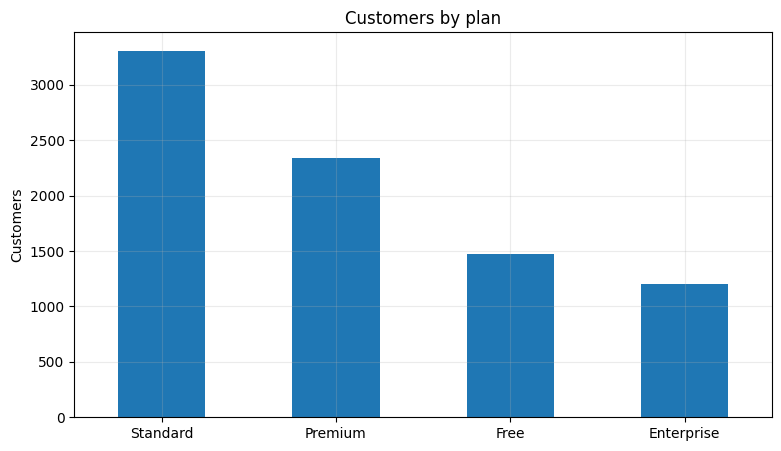

In [12]:
customers["Plan Type"].value_counts().plot(kind="bar")
plt.title("Customers by plan")
plt.xlabel("")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()


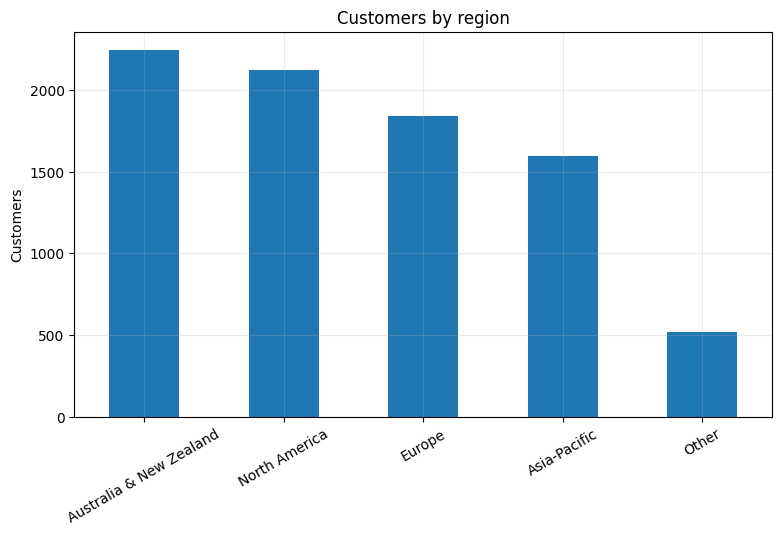

In [13]:
customers["Region"].value_counts().plot(kind="bar")
plt.title("Customers by region")
plt.xlabel("")
plt.ylabel("Customers")
plt.xticks(rotation=30)
plt.show()


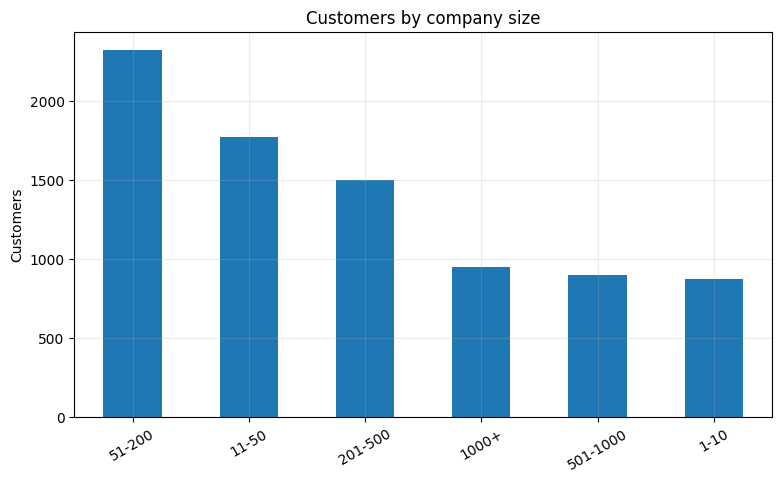

In [14]:
customers["Company Size"].value_counts().plot(kind="bar")
plt.title("Customers by company size")
plt.xlabel("")
plt.ylabel("Customers")
plt.xticks(rotation=30)
plt.show()


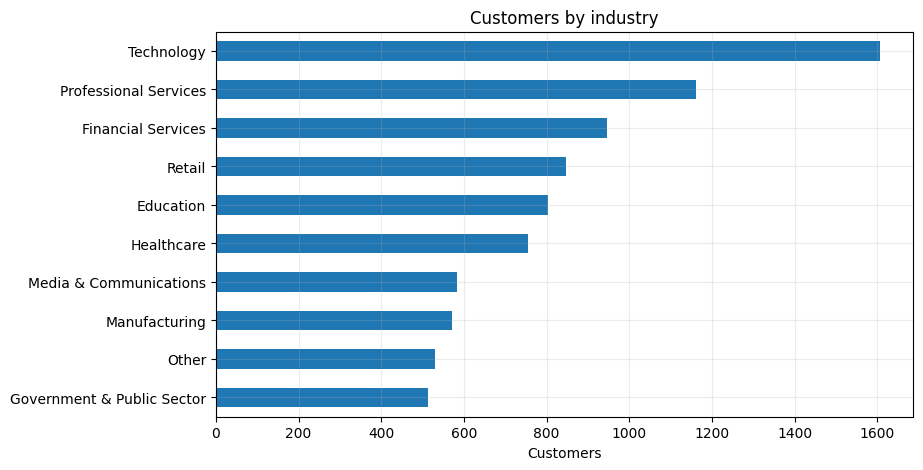

In [15]:
customers["Industry"].value_counts().sort_values().plot(kind="barh")
plt.title("Customers by industry")
plt.xlabel("Customers")
plt.ylabel("")
plt.show()


## Ticket breakdown

In [16]:
tickets["Ticket Status"].value_counts()


Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

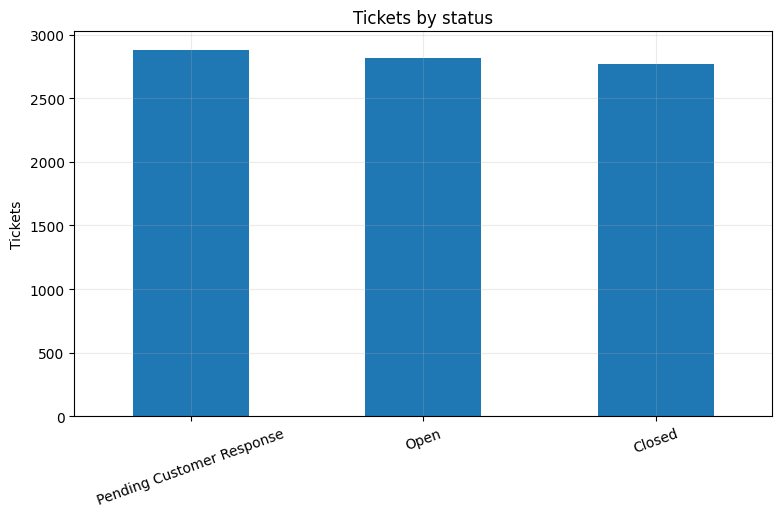

In [17]:
tickets["Ticket Status"].value_counts().plot(kind="bar")
plt.title("Tickets by status")
plt.xlabel("")
plt.ylabel("Tickets")
plt.xticks(rotation=20)
plt.show()


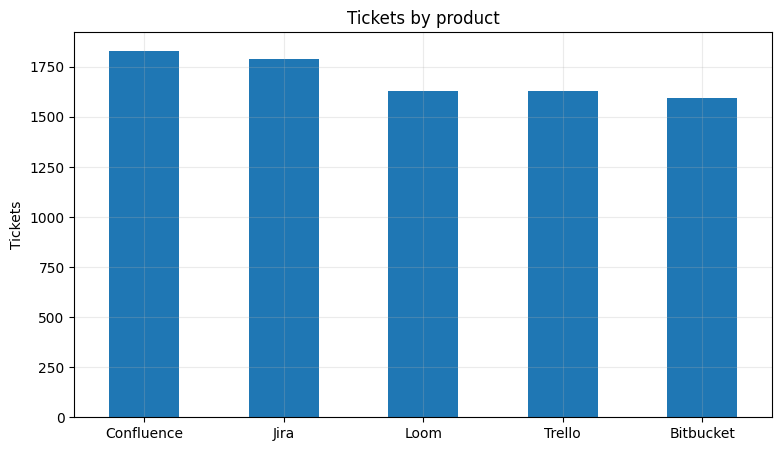

In [18]:
tickets["Product Purchased"].value_counts().plot(kind="bar")
plt.title("Tickets by product")
plt.xlabel("")
plt.ylabel("Tickets")
plt.xticks(rotation=0)
plt.show()


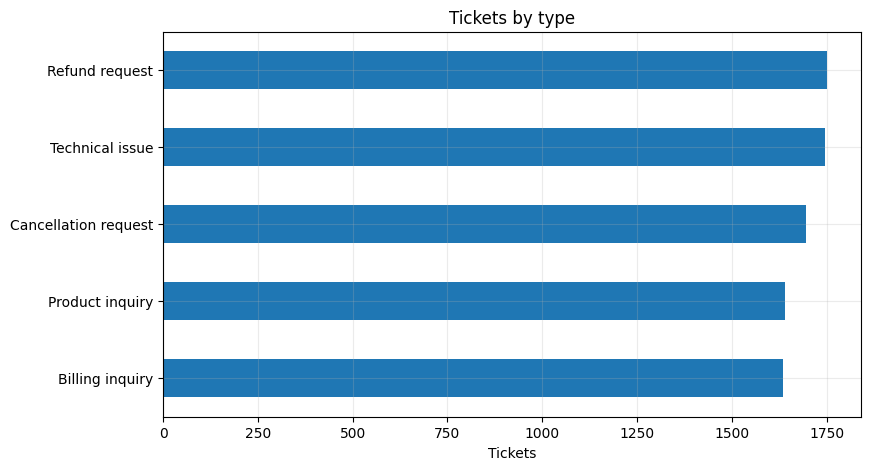

In [19]:
tickets["Ticket Type"].value_counts().sort_values().plot(kind="barh")
plt.title("Tickets by type")
plt.xlabel("Tickets")
plt.ylabel("")
plt.show()


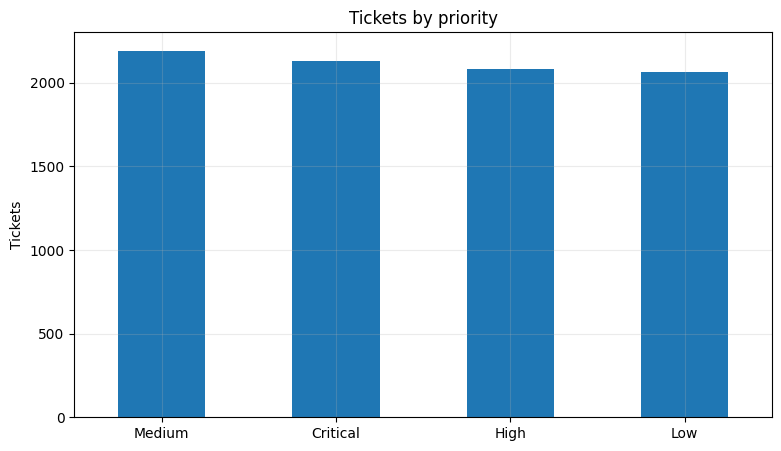

In [20]:
tickets["Ticket Priority"].value_counts().plot(kind="bar")
plt.title("Tickets by priority")
plt.xlabel("")
plt.ylabel("Tickets")
plt.xticks(rotation=0)
plt.show()


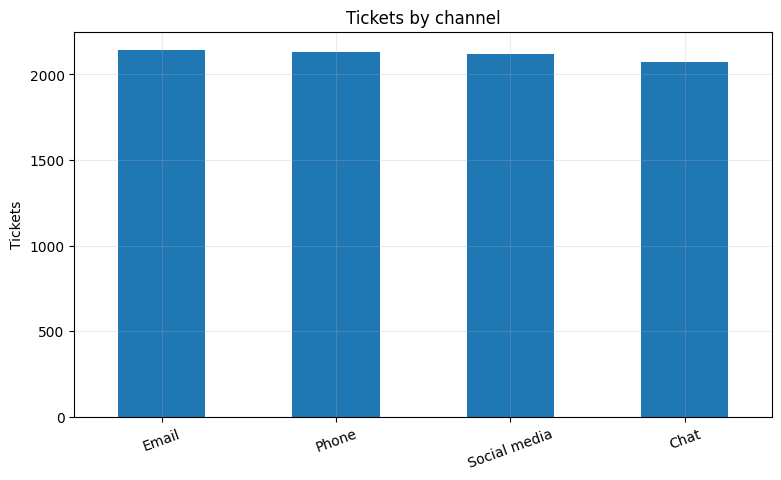

In [21]:
tickets["Ticket Channel"].value_counts().plot(kind="bar")
plt.title("Tickets by channel")
plt.xlabel("")
plt.ylabel("Tickets")
plt.xticks(rotation=20)
plt.show()


## Customer satisfaction

In [22]:
csat = tickets["Customer Satisfaction Rating"].dropna()

print("Average CSAT:", round(csat.mean(), 2))
print("Median CSAT:", csat.median())
print("Low CSAT (1-2):", round((csat <= 2).mean() * 100, 2), "%")
print("High CSAT (4-5):", round((csat >= 4).mean() * 100, 2), "%")


Average CSAT: 2.99
Median CSAT: 3.0
Low CSAT (1-2): 39.8 %
High CSAT (4-5): 39.26 %


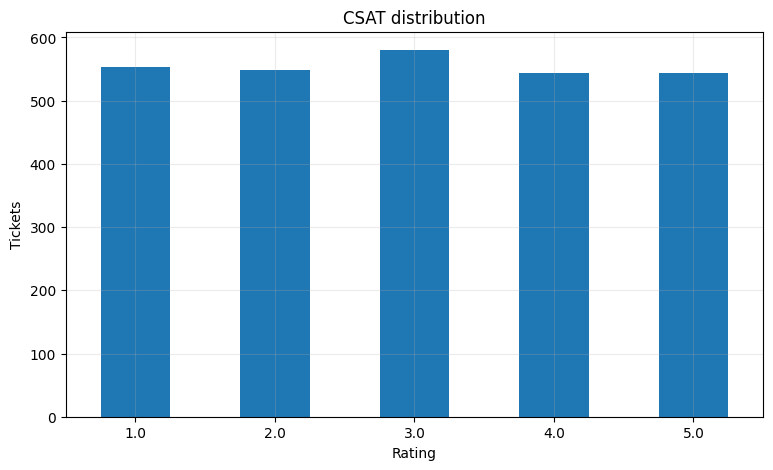

In [23]:
csat.value_counts().sort_index().plot(kind="bar")
plt.title("CSAT distribution")
plt.xlabel("Rating")
plt.ylabel("Tickets")
plt.xticks(rotation=0)
plt.show()


## CSAT by product

In [24]:
csat_by_product = (
    tickets.groupby("Product Purchased")
    .agg(
        tickets=("Ticket ID", "count"),
        avg_csat=("Customer Satisfaction Rating", "mean"),
        low_csat_pct=("Customer Satisfaction Rating",
                      lambda x: (x.dropna() <= 2).mean() * 100)
    )
    .round(2)
    .sort_values("avg_csat")
)

csat_by_product


,tickets,avg_csat,low_csat_pct
Product Purchased,,,
Bitbucket,1595,2.94,40.99
Jira,1787,2.96,39.97
Trello,1627,2.97,39.89
Confluence,1831,3.02,38.90
Loom,1629,3.06,39.30


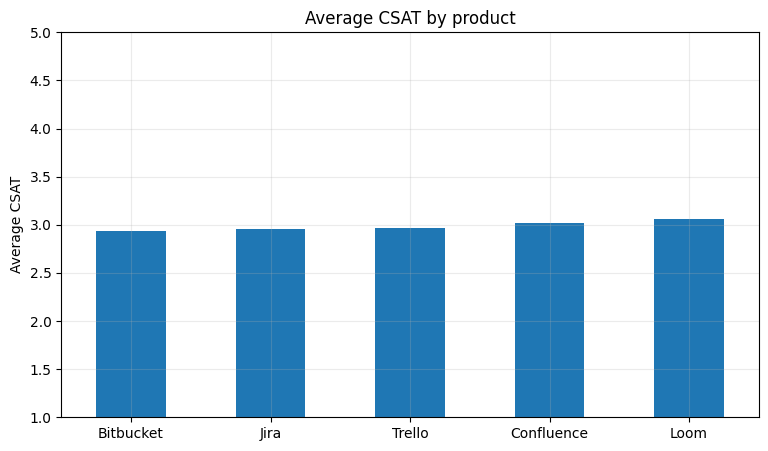

In [25]:
csat_by_product["avg_csat"].plot(kind="bar")
plt.title("Average CSAT by product")
plt.xlabel("")
plt.ylabel("Average CSAT")
plt.ylim(1, 5)
plt.xticks(rotation=0)
plt.show()


## CSAT by priority / channel / ticket type

In [26]:
for col in ["Ticket Priority", "Ticket Channel", "Ticket Type"]:
    summary = (
        tickets.groupby(col)
        .agg(
            tickets=("Ticket ID", "count"),
            avg_csat=("Customer Satisfaction Rating", "mean")
        )
        .sort_values("avg_csat")
        .round(2)
    )

    print("\n", col.upper())
    display(summary)



 TICKET PRIORITY


,tickets,avg_csat
Ticket Priority,,
Critical,2129,2.96
Medium,2192,2.98
High,2085,2.98
Low,2063,3.05



 TICKET CHANNEL


,tickets,avg_csat
Ticket Channel,,
Phone,2132,2.95
Email,2143,2.96
Social media,2121,2.97
Chat,2073,3.08



 TICKET TYPE


,tickets,avg_csat
Ticket Type,,
Refund request,1752,2.93
Technical issue,1747,2.96
Product inquiry,1641,3.02
Billing inquiry,1634,3.03
Cancellation request,1695,3.03


## Product usage

In [27]:
usage[[
    "Active Days",
    "Sessions",
    "Product Actions",
    "Collaborators",
    "Integrations Used"
]].describe().round(2)


,Active Days,Sessions,Product Actions,Collaborators,Integrations Used
count,42210.00,42210.00,42210.00,42210.00,42210.00
mean,8.72,17.46,100.25,11.07,3.17
std,4.96,9.72,63.85,3.76,2.00
min,1.00,1.00,3.00,2.00,0.00
25%,5.00,11.00,56.00,8.00,2.00
50%,8.00,16.00,87.00,11.00,3.00
75%,11.00,22.00,130.00,14.00,5.00
max,31.00,105.00,794.00,23.00,11.00


In [28]:
usage_by_product = (
    usage.groupby("Product")
    .agg(
        customers=("Customer ID", "nunique"),
        avg_active_days=("Active Days", "mean"),
        avg_sessions=("Sessions", "mean"),
        avg_actions=("Product Actions", "mean"),
        avg_collaborators=("Collaborators", "mean"),
        avg_integrations=("Integrations Used", "mean")
    )
    .round(2)
)

usage_by_product


,customers,avg_active_days,avg_sessions,avg_actions,avg_collaborators,avg_integrations
Product,,,,,,
Bitbucket,1590,9.35,18.70,107.26,11.28,3.22
Confluence,1825,8.64,17.30,99.85,11.09,3.15
Jira,1779,10.00,20.11,115.33,11.46,3.19
Loom,1627,6.75,13.45,77.54,10.39,3.17
Trello,1621,8.78,17.54,100.05,11.11,3.11


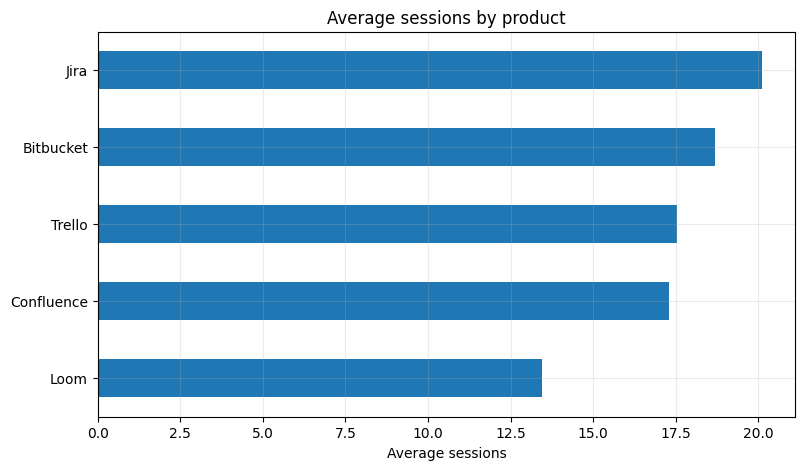

In [29]:
usage_by_product["avg_sessions"].sort_values().plot(kind="barh")
plt.title("Average sessions by product")
plt.xlabel("Average sessions")
plt.ylabel("")
plt.show()


## Usage over time

In [30]:
usage["Month"] = pd.to_datetime(usage["Month"])

monthly_usage = (
    usage.groupby("Month")
    .agg(
        avg_sessions=("Sessions", "mean"),
        avg_active_days=("Active Days", "mean"),
        avg_actions=("Product Actions", "mean")
    )
    .reset_index()
)

monthly_usage


,Month,avg_sessions,avg_active_days,avg_actions
0,2023-01-01,17.506752,8.730633,100.994077
1,2023-02-01,17.504975,8.764985,100.536840
2,2023-03-01,17.530443,8.735134,100.420161
3,2023-04-01,17.409026,8.708244,100.014096
4,2023-05-01,17.344587,8.683724,99.274343


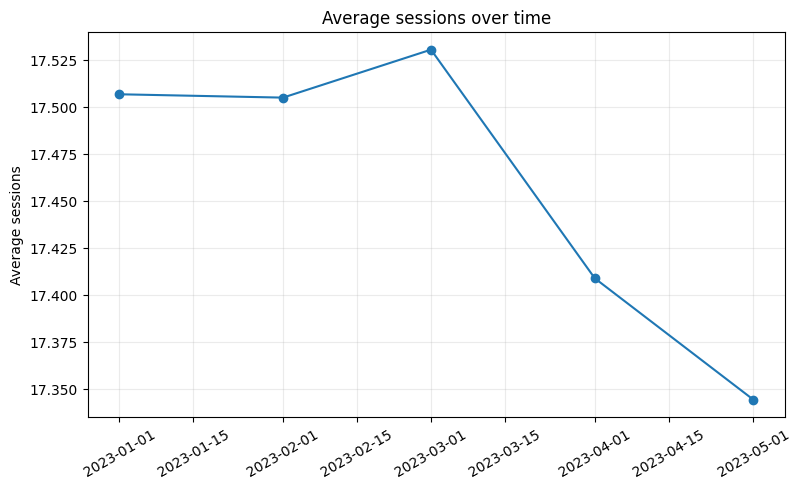

In [31]:
plt.plot(monthly_usage["Month"], monthly_usage["avg_sessions"], marker="o")
plt.title("Average sessions over time")
plt.xlabel("")
plt.ylabel("Average sessions")
plt.xticks(rotation=30)
plt.show()


## Join tickets to customer info

In [32]:
tickets_customer = tickets.merge(
    customers[[
        "Customer ID",
        "Customer Email",
        "Plan Type",
        "Industry",
        "Region",
        "Company Size"
    ]],
    on="Customer Email",
    how="left"
)

tickets_customer.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Customer ID,Plan Type,Industry,Region,Company Size
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN,CUST01085,Free,Technology,Europe,1000+
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN,CUST01335,Standard,Financial Services,North America,11-50
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0,CUST02581,Premium,Media & Communications,North America,201-500
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0,CUST00742,Premium,Professional Services,Australia & New Zealand,51-200
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0,CUST00741,Enterprise,Manufacturing,Australia & New Zealand,501-1000


## Support metrics by plan

In [33]:
support_by_plan = (
    tickets_customer.groupby("Plan Type")
    .agg(
        customers=("Customer ID", "nunique"),
        tickets=("Ticket ID", "count"),
        avg_csat=("Customer Satisfaction Rating", "mean"),
        critical_pct=("Ticket Priority", lambda x: (x == "Critical").mean() * 100),
        closed_pct=("Ticket Status", lambda x: (x == "Closed").mean() * 100)
    )
    .round(2)
)

support_by_plan["tickets_per_customer"] = (
    support_by_plan["tickets"] / support_by_plan["customers"]
).round(2)

support_by_plan


,customers,tickets,avg_csat,critical_pct,closed_pct,tickets_per_customer
Plan Type,,,,,,
Enterprise,1202,1213,3.04,25.06,32.40,1.01
Free,1472,1506,3.02,26.03,33.07,1.02
Premium,2337,2383,2.99,24.72,32.35,1.02
Standard,3309,3367,2.96,25.07,32.88,1.02


## Usage by plan

In [34]:
usage_customer = usage.merge(
    customers[["Customer ID", "Plan Type", "Company Size", "Region", "Industry"]],
    on="Customer ID",
    how="left"
)

usage_by_plan = (
    usage_customer.groupby("Plan Type")
    .agg(
        customers=("Customer ID", "nunique"),
        avg_sessions=("Sessions", "mean"),
        avg_active_days=("Active Days", "mean"),
        avg_actions=("Product Actions", "mean"),
        avg_integrations=("Integrations Used", "mean")
    )
    .round(2)
)

usage_by_plan


,customers,avg_sessions,avg_active_days,avg_actions,avg_integrations
Plan Type,,,,,
Enterprise,1202,23.02,11.52,132.72,5.99
Free,1472,10.57,5.33,60.57,1.14
Premium,2337,20.30,10.11,116.69,4.10
Standard,3309,16.52,8.25,94.63,2.40


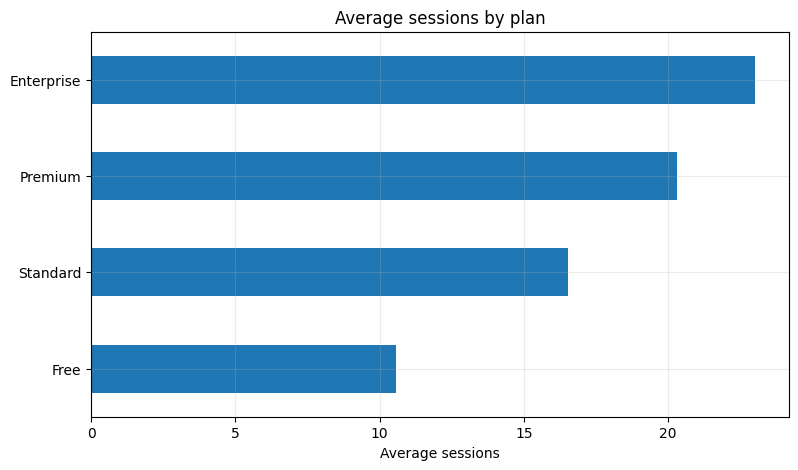

In [35]:
usage_by_plan["avg_sessions"].sort_values().plot(kind="barh")
plt.title("Average sessions by plan")
plt.xlabel("Average sessions")
plt.ylabel("")
plt.show()


## Customer-level table

In [36]:
ticket_summary = (
    tickets_customer.groupby("Customer ID")
    .agg(
        ticket_count=("Ticket ID", "count"),
        avg_csat=("Customer Satisfaction Rating", "mean"),
        critical_tickets=("Ticket Priority", lambda x: (x == "Critical").sum()),
        low_csat_tickets=("Customer Satisfaction Rating",
                          lambda x: (x.dropna() <= 2).sum())
    )
    .reset_index()
)

usage_summary = (
    usage.groupby("Customer ID")
    .agg(
        avg_sessions=("Sessions", "mean"),
        avg_active_days=("Active Days", "mean"),
        avg_actions=("Product Actions", "mean"),
        avg_integrations=("Integrations Used", "mean")
    )
    .reset_index()
)

customer_summary = (
    customers
    .merge(ticket_summary, on="Customer ID", how="left")
    .merge(usage_summary, on="Customer ID", how="left")
)

customer_summary.head()


,Customer ID,Customer Name,Customer Email,Customer Age,Customer Gender,Industry,Region,Company Size,Plan Type,Account Created Date,ticket_count,avg_csat,critical_tickets,low_csat_tickets,avg_sessions,avg_active_days,avg_actions,avg_integrations
0,CUST00001,Robert Downs,aanderson@example.com,42,Male,Technology,Europe,201-500,Standard,2020-12-20,1,NaN,0,0,8.2,4.2,37.8,2.8
1,CUST00002,Cesar Jensen,aanderson@example.net,35,Other,Retail,Asia-Pacific,201-500,Standard,2020-06-15,1,NaN,0,0,13.2,6.2,74.8,2.8
2,CUST00003,Angela Tran,aarnold@example.com,52,Other,Education,Asia-Pacific,1000+,Free,2020-10-24,1,5.0,0,0,8.6,4.6,38.6,1.2
3,CUST00004,Justin Estrada,aaron01@example.com,45,Female,Professional Services,Europe,11-50,Enterprise,2019-11-13,1,NaN,0,0,39.8,19.4,279.0,6.0
4,CUST00005,James Santos,aaron49@example.org,22,Other,Professional Services,Australia & New Zealand,501-1000,Standard,2019-04-21,1,NaN,0,0,8.8,5.0,34.6,2.2


## Do customers with worse support use the products less?

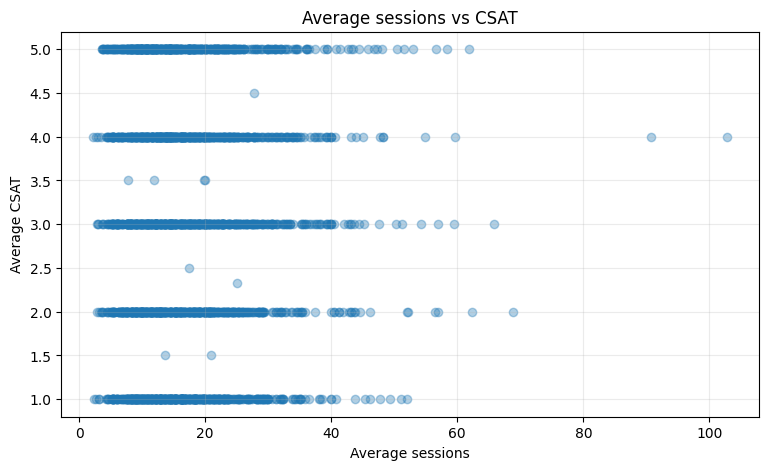

Correlation: 0.015


In [37]:
plot_data = customer_summary.dropna(subset=["avg_csat", "avg_sessions"])

plt.scatter(
    plot_data["avg_sessions"],
    plot_data["avg_csat"],
    alpha=0.35
)

plt.title("Average sessions vs CSAT")
plt.xlabel("Average sessions")
plt.ylabel("Average CSAT")
plt.show()

print(
    "Correlation:",
    round(plot_data[["avg_sessions", "avg_csat"]].corr().iloc[0, 1], 3)
)


## Usage change by customer

In [38]:
monthly_customer = (
    usage.groupby(["Customer ID", "Month"], as_index=False)["Sessions"]
    .sum()
    .sort_values(["Customer ID", "Month"])
)

usage_change = (
    monthly_customer.groupby("Customer ID")
    .agg(
        first_sessions=("Sessions", "first"),
        last_sessions=("Sessions", "last")
    )
    .reset_index()
)

usage_change["session_change_pct"] = np.where(
    usage_change["first_sessions"] > 0,
    (usage_change["last_sessions"] - usage_change["first_sessions"])
    / usage_change["first_sessions"] * 100,
    np.nan
)

usage_change["session_change_pct"].describe()


count    8320.000000
mean        9.629421
std        71.825048
min       -94.117647
25%       -18.181818
50%         0.000000
75%        20.000000
max      1600.000000
Name: session_change_pct, dtype: float64

In [39]:
customer_summary = customer_summary.merge(
    usage_change[["Customer ID", "session_change_pct"]],
    on="Customer ID",
    how="left"
)

customer_summary[[
    "Customer ID",
    "Plan Type",
    "ticket_count",
    "avg_csat",
    "avg_sessions",
    "session_change_pct"
]].head()


,Customer ID,Plan Type,ticket_count,avg_csat,avg_sessions,session_change_pct
0,CUST00001,Standard,1,NaN,8.2,42.857143
1,CUST00002,Standard,1,NaN,13.2,-42.105263
2,CUST00003,Free,1,5.0,8.6,-71.428571
3,CUST00004,Enterprise,1,NaN,39.8,27.272727
4,CUST00005,Standard,1,NaN,8.8,20.000000


## Simple risk flag

In [40]:
# Just an exploratory flag — not a churn prediction.

customer_summary["usage_decline"] = (
    customer_summary["session_change_pct"] <= -25
)

customer_summary["poor_support"] = (
    (customer_summary["avg_csat"] <= 2) |
    (customer_summary["critical_tickets"] >= 1)
)

customer_summary["risk_flag"] = (
    customer_summary["usage_decline"] &
    customer_summary["poor_support"]
)

print("Customers with falling usage:",
      customer_summary["usage_decline"].sum())

print("Customers with poor support signals:",
      customer_summary["poor_support"].sum())

print("Customers with both:",
      customer_summary["risk_flag"].sum())

print(
    "Share of customers flagged:",
    round(customer_summary["risk_flag"].mean() * 100, 2),
    "%"
)


Customers with falling usage: 1524
Customers with poor support signals: 2904
Customers with both: 606
Share of customers flagged: 7.28 %


## Risk by plan

In [41]:
risk_by_plan = (
    customer_summary.groupby("Plan Type")
    .agg(
        customers=("Customer ID", "count"),
        flagged=("risk_flag", "sum"),
        risk_pct=("risk_flag", "mean"),
        avg_csat=("avg_csat", "mean"),
        avg_usage_change=("session_change_pct", "mean")
    )
)

risk_by_plan["risk_pct"] *= 100
risk_by_plan.round(2).sort_values("risk_pct", ascending=False)


,customers,flagged,risk_pct,avg_csat,avg_usage_change
Plan Type,,,,,
Free,1472,166,11.28,3.01,20.11
Standard,3309,241,7.28,2.96,10.24
Premium,2337,136,5.82,3.00,5.62
Enterprise,1202,63,5.24,3.04,2.91


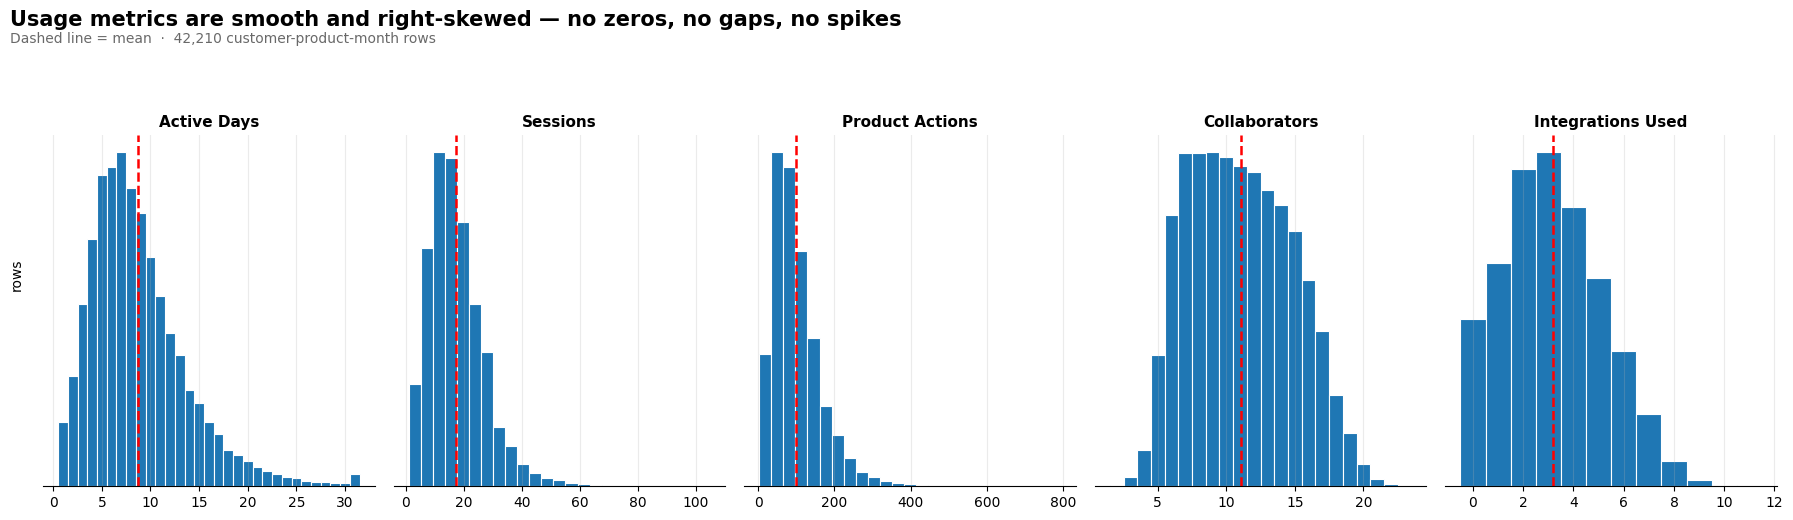

In [42]:
import numpy as np
import matplotlib.pyplot as plt

usage_metrics = [
    "Active Days",
    "Sessions",
    "Product Actions",
    "Collaborators",
    "Integrations Used"
]

fig, axes = plt.subplots(
    1,
    len(usage_metrics),
    figsize=(18, 5)
)
axes = np.asarray(axes).ravel()

for ax, col in zip(axes, usage_metrics):
    x = usage[col].dropna()

    if col in ["Collaborators", "Integrations Used", "Active Days"]:
        bins = np.arange(
            np.floor(x.min()) - 0.5,
            np.ceil(x.max()) + 1.5,
            1
        )
    else:
        bins = 25

    ax.hist(
        x,
        bins=bins,
        edgecolor="white",
        linewidth=0.8
    )

    ax.axvline(
        x.mean(),
        linestyle="--",
        linewidth=1.8,
        color="red"
    )

    ax.set_title(col, fontweight="bold", fontsize=11)
    ax.set_ylabel("")
    ax.set_yticks([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

fig.text(
    0.01,
    0.50,
    "rows",
    va="center",
    rotation="vertical",
    fontsize=10
)

fig.suptitle(
    "Usage metrics are smooth and right-skewed — no zeros, no gaps, no spikes",
    x=0.01,
    y=1.03,
    ha="left",
    fontsize=15,
    fontweight="bold"
)

fig.text(
    0.01,
    0.965,
    f"Dashed line = mean  ·  {len(usage):,} customer-product-month rows",
    fontsize=10,
    color="dimgray"
)

plt.tight_layout(rect=[0.02, 0, 1, 0.92])
plt.show()